In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

import moscot as mt
import moscot.plotting as mpl
from moscot.problems.time import TemporalProblem


In [2]:
import os
os.chdir("/projects/bgdb/asachan/methods/OT_FM")  # adjust path if needed
from utils import *

In [3]:
plt.rcParams["legend.scatterpoints"] = 1
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=200)

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

#### Load and combine scRNA and scATAC-seq data (multiome - so cell barcodes are shared)

In [4]:
rna_path = '/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/stream_input_filtered_cells_v7.h5ad'
atac_path = '/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/adata_aggregated_peak.leiden.h5ad'

In [5]:
rna_adata = sc.read_h5ad(rna_path)
rna_adata

AnnData object with n_obs × n_vars = 28494 × 3018
    obs: 'cell_type_major', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'topic_22', 'topic_23', 'topic_24', 'topic_25', 'topic_26', 'topic_27', 'topic_28', 'topic_29', 'topic_30', 'topic_31', 'leiden', 'sub_cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'DM_EigenValues', 'cell_type_major_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sub_cell_type_colors', 'topic_dendogram', 'umap'
    obsm: 'DM_EigenVectors', 'X_joint_umap_features',

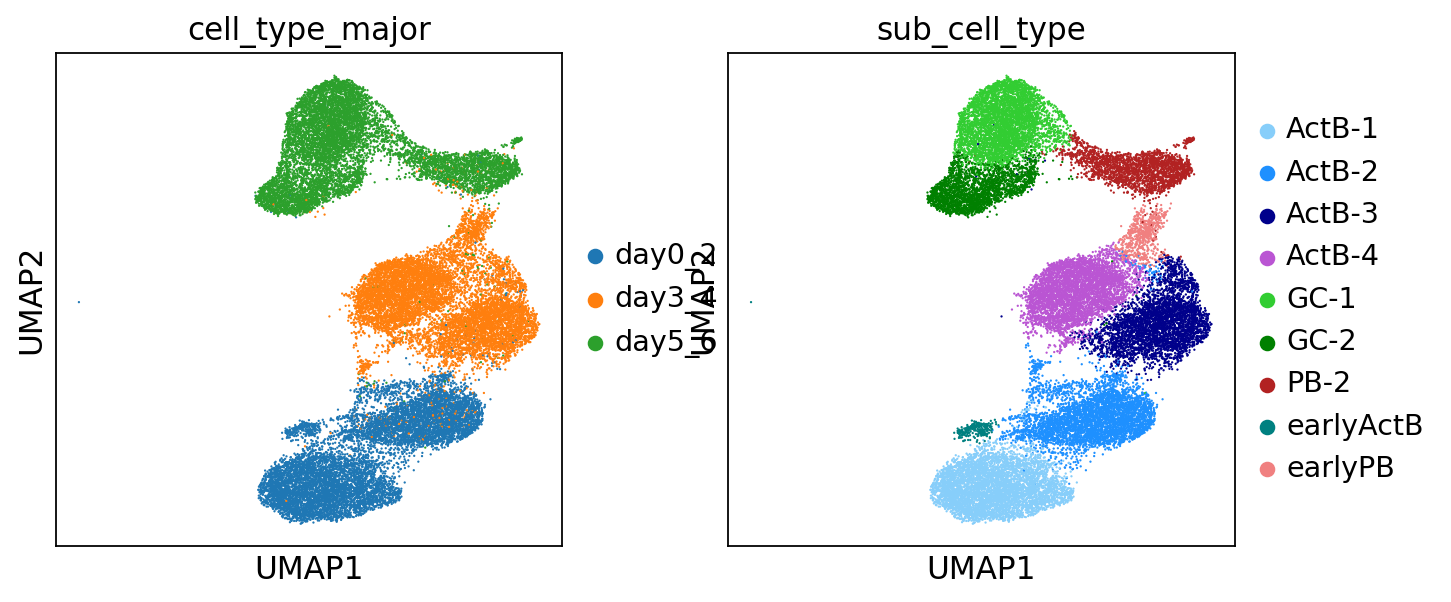

In [6]:
sc.pl.umap(rna_adata, color=['cell_type_major', 'sub_cell_type'])

In [7]:
rna_adata.obs['cell_type_major']

AAACAGCCAAGCCACT-3    day5_6
AAACAGCCAAGGTGCA-1    day0_2
AAACAGCCAAGTTATC-1    day0_2
AAACAGCCAATAGCCC-1    day0_2
AAACAGCCAGTTAGCC-1    day0_2
                       ...  
TTTGTTGGTTTACGTC-1    day0_2
TTTGTTGGTTTAGTCC-1    day0_2
TTTGTTGGTTTATGGG-2    day3_4
TTTGTTGGTTTCCTCC-3    day5_6
TTTGTTGGTTTGAGGC-2    day3_4
Name: cell_type_major, Length: 28494, dtype: category
Categories (3, str): ['day0_2', 'day3_4', 'day5_6']

In [8]:
atac_adata = sc.read_h5ad(atac_path)
atac_adata

AnnData object with n_obs × n_vars = 32418 × 191255
    obs: 'cell_type_major', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'cell_index', 'leiden_joint'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'topic_dendogram'
    obsm: 'X_joint_umap_features', 'X_topic_compositions', 'X_umap_features'
    varm: 'topic_feature_activations', 'topic_feature_compositions'
    layers: 'counts'

In [9]:
atac_adata.var

,gene_ids,feature_types,genome
chr1:9809-10677,chr1:9809-10677,Peaks,GRCh38
chr1:28988-29868,chr1:28988-29868,Peaks,GRCh38
chr1:180722-180992,chr1:180722-180992,Peaks,GRCh38
chr1:181093-181802,chr1:181093-181802,Peaks,GRCh38
chr1:267555-268452,chr1:267555-268452,Peaks,GRCh38
...,...,...,...
KI270713.1:29710-30533,KI270713.1:29710-30533,Peaks,GRCh38
KI270713.1:31281-32210,KI270713.1:31281-32210,Peaks,GRCh38
KI270713.1:32672-33147,KI270713.1:32672-33147,Peaks,GRCh38
KI270713.1:33255-33832,KI270713.1:33255-33832,Peaks,GRCh38


In [10]:
# check shared cells
shared = rna_adata.obs_names.intersection(atac_adata.obs_names)
print("shared cells:", len(shared))

shared cells: 28494


In [11]:
atac_adata = atac_adata[shared].copy()

# Import mudata

In [12]:
import muon as mu

mdata = mu.read_h5mu('/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/rna_atac_multivi.h5mu')
mdata

MuData object with n_obs × n_vars = 28494 × 194273
  obs:	'_indices', '_scvi_batch', '_scvi_labels'
  var:	'gene_ids', 'feature_types', 'genome'
  uns:	'_scvi_manager_uuid', '_scvi_uuid'
  obsm:	'X_MultiVI'
  2 modalities
    rna:	28494 x 3018
      obs:	'cell_type_major', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'topic_22', 'topic_23', 'topic_24', 'topic_25', 'topic_26', 'topic_27', 'topic_28', 'topic_29', 'topic_30', 'topic_31', 'leiden', 'sub_cell_type'
      var:	'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'DM_EigenValues', 'cell_type_major_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sub_cell_type_colors', 'topic_dendogram', 'umap'
      obsm:	'DM_EigenVectors', 'X_joint_umap_features', 'X_pca', 'X_topic_compositions', 'X_umap', 'X_umap_features'
      varm:	'PCs', 'topic_feature_activations', 'topic_feature_compositions'
      layers:	'MAGIC_imputed_data', 'counts'
      obsp:	'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'
    atac:	28494 x 191255
      obs:	'cell_type_major', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'cell_index', 'leiden_joint'
      var:	'gene_ids', 'feature_types', 'genome'
      uns:	'topic_dendogram'
      obsm:	'X_joint_umap_features', 'X_topic_compositions', 'X_umap_features'
      varm:	'topic_feature_activations', 'topic_feature_compositions'
      layers:	'counts'

In [13]:
X = mdata.obsm["X_MultiVI"]
X.shape

(28494, 11)

In [14]:
common = rna_adata.obs_names.intersection(mdata.obs_names)
assert len(common) == rna_adata.n_obs == mdata.n_obs

rna_adata.obsm["X_MultiVI"] = mdata[rna_adata.obs_names].obsm["X_MultiVI"]


### Cleanup cell states by day

In [15]:
# 'ActB-1',
#  'ActB-2',
#  'ActB-3',
#  'ActB-4',
#  'GC-1',
#  'GC-2',
#  'PB-2',
#  'earlyActB',
#  'earlyPB'
adata_subset = rna_adata[rna_adata.obs['sub_cell_type'] == "PB-2"]

### keeping only the cell types that are present in the day-slot with population >100

In [16]:
# keeping only the cell types that are present in the day-slot with population >100
adata_subset.obs['cell_type_major'].value_counts()

cell_type_major
day5_6    2259
day3_4      78
day0_2       8
Name: count, dtype: int64

In [17]:
keep_by_day = {
    "day0_2": ["earlyActB", "ActB-1", "ActB-2"],
    "day3_4": ["ActB-2", "ActB-3", "ActB-4", "earlyPB"],
    "day5_6": ["GC-1", "GC-2", "PB-2"],
}

day_key = "cell_type_major"
ct_key  = "sub_cell_type"

mask = rna_adata.obs.apply(lambda r: r[ct_key] in keep_by_day.get(r[day_key], []), axis=1)

adata_asym = rna_adata[mask].copy()

# cleanup
adata_asym.obs[ct_key] = adata_asym.obs[ct_key].astype("category").cat.remove_unused_categories()
adata_asym.obs[day_key] = adata_asym.obs[day_key].astype("category").cat.remove_unused_categories()

In [18]:
adata_asym

AnnData object with n_obs × n_vars = 28243 × 3018
    obs: 'cell_type_major', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'topic_22', 'topic_23', 'topic_24', 'topic_25', 'topic_26', 'topic_27', 'topic_28', 'topic_29', 'topic_30', 'topic_31', 'leiden', 'sub_cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'DM_EigenValues', 'cell_type_major_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sub_cell_type_colors', 'topic_dendogram', 'umap'
    obsm: 'DM_EigenVectors', 'X_joint_umap_features',

In [19]:
# make temporal info numeric
def adapt_time(x):
    if x["cell_type_major"] == "day0_2":
        return 1.5
    if x["cell_type_major"] == "day3_4":
        return 3.5
    if x["cell_type_major"] == "day5_6":
        return 5.5
    raise ValueError

adata_asym.obs["cell_type_major"] = adata_asym.obs.apply(adapt_time, axis=1).astype("category")

# OT solver

In [20]:
# instantiate temporal OT problem
tp0 = TemporalProblem(adata_asym)
tp0 = tp0.prepare(time_key="cell_type_major", joint_attr="X_MultiVI")

In [23]:
import networkx as nx

dfs = {}
batch_column = "cell_type_major"
unique_batches = [1.5, 3.5, 5.5]

# pair wise WOT
for i in range(len(unique_batches) - 1):
    batch1 = unique_batches[i]
    batch2 = unique_batches[i + 1]

    indices = np.where(
        (adata_asym.obs[batch_column] == batch1) | (adata_asym.obs[batch_column] == batch2)
    )[0]
    adata_subset = adata_asym[indices]

    sc.pp.neighbors(adata_subset, use_rep="X_MultiVI", n_neighbors=30)
    G = nx.from_numpy_array(adata_subset.obsp["connectivities"].todense())
    assert nx.is_connected(G)

    # store the kNN graph as a dense pandas df and save it in a dict
    dfs[(batch1, batch2)] = pd.DataFrame(
        index=adata_subset.obs_names,
        columns=adata_subset.obs_names,
        data=adata_subset.obsp["connectivities"].todense().astype("float"),
    )

In [24]:
for (t1, t2) in [(1.5, 3.5), (3.5, 5.5)]:
    prob = tp0[t1, t2]

    expected = prob.adata_src.obs_names.append(prob.adata_tgt.obs_names)  # Index
    Gdf = dfs[(t1, t2)].loc[expected, expected].astype(float)

    prob.set_graph_xy(Gdf, t=100.0)


In [25]:
# epsilon: entropic regularization strength
tp0 = tp0.solve(epsilon=1e-3, scale_cost="mean", max_iterations=1e7)

INFO     Solving `2` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(9282, 9111)].                                  


W0323 11:32:35.903367 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:32:37.710342 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:32:43.020808 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:32:43.919595 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:32:44.070510 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:32:44.482332 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:32:44.569719 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:32:45.389079 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11

INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(9850, 9282)].                                  


W0323 11:34:45.807085 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:34:45.875991 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:34:45.924295 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:34:45.997917 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:34:46.116762 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:34:46.282796 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:35:11.707652 1553747 gemm_fusion_autotuner.cc:1053] Compiling 60 configs for 2 fusions on a single thread.
W0323 11:35:11.709139 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:35:11.7

In [26]:
import cloudpickle
tmp_dir = "/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/tmp"
with open(f'{tmp_dir}/tp0_asym.pkl', 'wb') as f:
    cloudpickle.dump(tp0, f)
print("Saved!")

Saved!


In [27]:
import numpy as np
import scipy.sparse as sp

T_15_35 = tp0[1.5, 3.5].solution.transport_matrix
T_35_55 = tp0[3.5, 5.5].solution.transport_matrix

# JAX -> NumPy
T_15_35_np = np.asarray(T_15_35)
T_35_55_np = np.asarray(T_35_55)

# NumPy -> sparse (CSR)
T_15_35_csr = sp.csr_matrix(T_15_35_np)
T_35_55_csr = sp.csr_matrix(T_35_55_np)

sp.save_npz(os.path.join(tmp_dir, "T_1.5_3.5.npz"), T_15_35_csr)
sp.save_npz(os.path.join(tmp_dir, "T_3.5_5.5.npz"), T_35_55_csr)

W0323 11:36:02.213871 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:36:02.237740 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:36:02.259902 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:36:02.317440 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:36:02.390986 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:36:02.442936 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:36:02.494906 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11:36:02.546864 1553747 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0323 11

### Vizualize

In [20]:
# load tp0 object
import pickle
with open('/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/tmp/tp0_asym.pkl', 'rb') as f:
    tp0 = pickle.load(f)


In [21]:
order_celltypes = ['earlyActB','ActB-1',
 'ActB-2',
 'ActB-3',
 'ActB-4',
 'earlyPB',
 'PB-2',
 'GC-1',
 'GC-2']

order_celltypes

['earlyActB',
 'ActB-1',
 'ActB-2',
 'ActB-3',
 'ActB-4',
 'earlyPB',
 'PB-2',
 'GC-1',
 'GC-2']

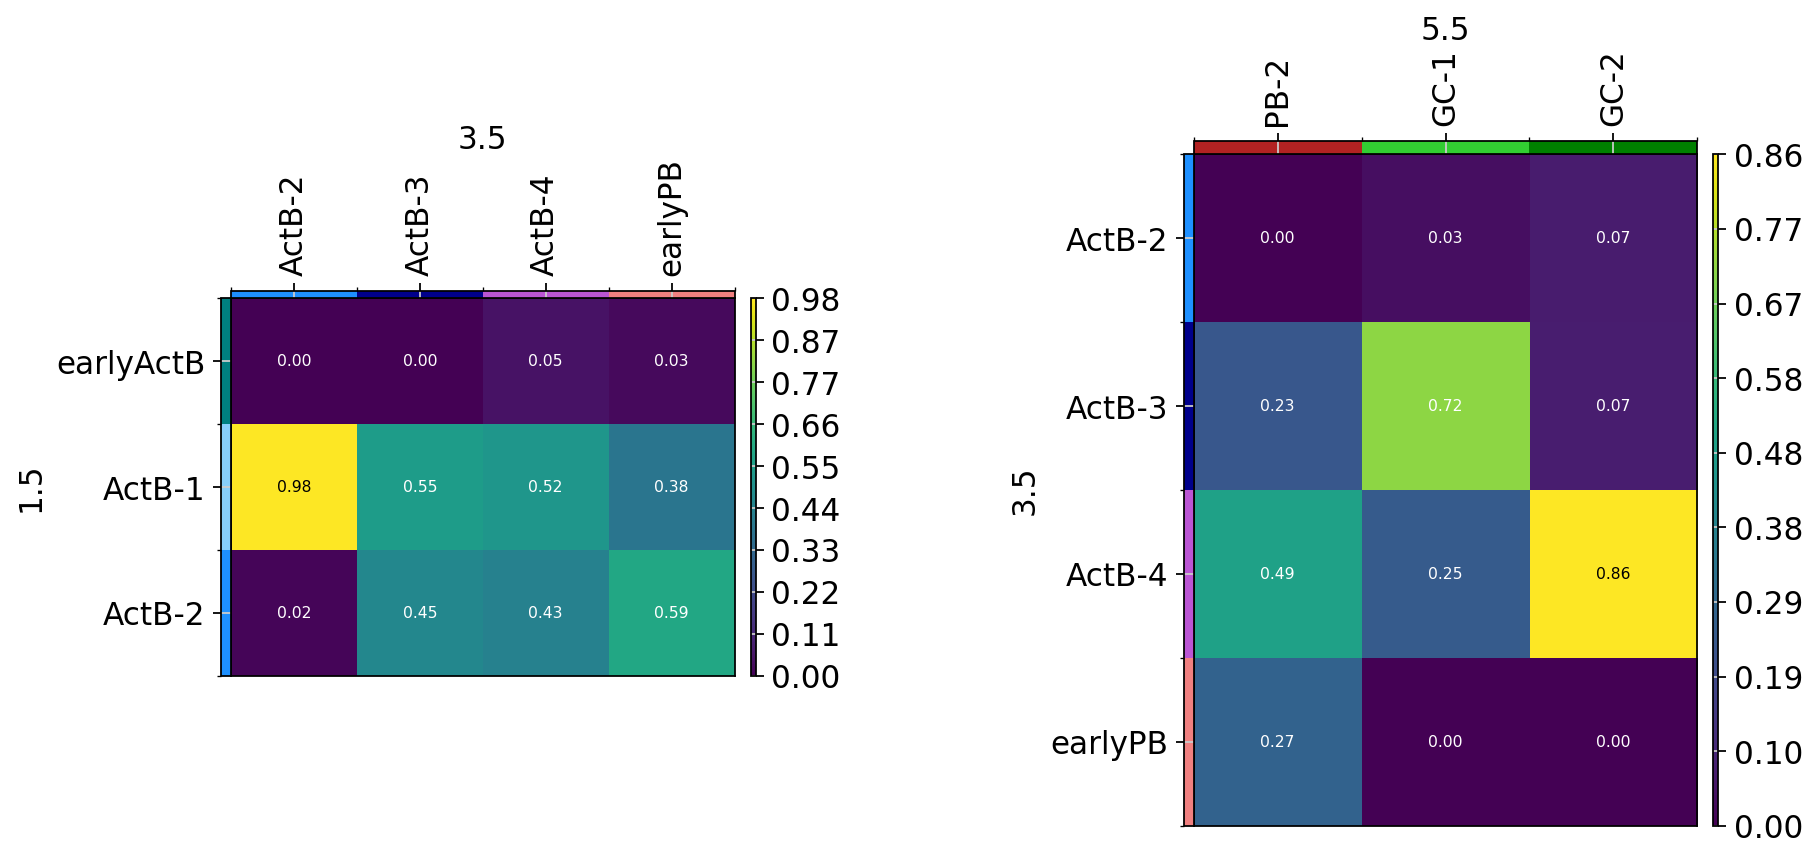

In [22]:
ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=False, # ancestor plots
    key_added="transitions_1.5_3.5_large",
)
ct_desc = tp0.cell_transition(
    3.5,
    5.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=False,
    key_added="transitions_3.5_5.5_large",
)

# Create a 1x2 grid of subplots
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

axes[0] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[0],
    key="transitions_1.5_3.5_large",
)

axes[1] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[1],
    key="transitions_3.5_5.5_large",
)


fig.subplots_adjust(wspace=0.8)
# save fig
#fig.savefig("/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/figs/ancestor_plots.pdf", dpi=300)


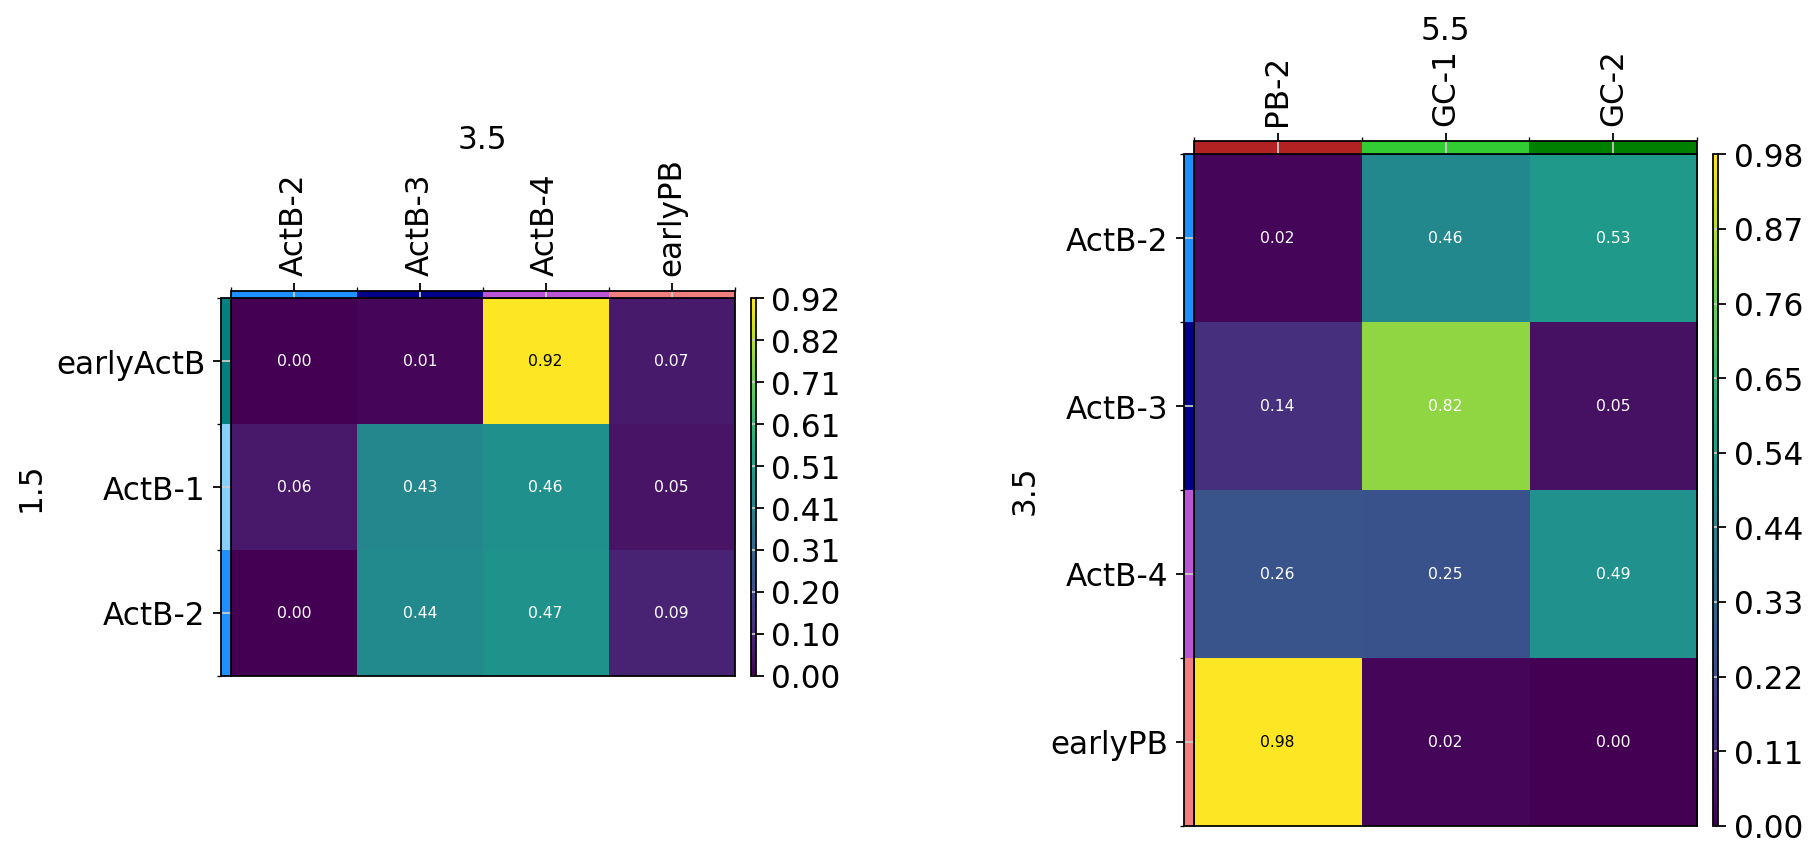

In [ ]:
ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=True,
    key_added="transitions_1.5_3.5",
)
ct_desc = tp0.cell_transition(
    3.5,
    5.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=True,
    key_added="transitions_3.5_5.5",
)

# Create a 1x2 grid of subplots
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

axes[0] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[0],
    key="transitions_1.5_3.5",
)

axes[1] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[1],
    key="transitions_3.5_5.5",
)


fig.subplots_adjust(wspace=0.8)
# save fig
#fig.savefig("/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/figs/descendant_plots.pdf", dpi=300)

W0320 19:25:10.671198  652349 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0320 19:25:10.787992  652349 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0320 19:25:10.812382  652349 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0320 19:25:10.854150  652349 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0320 19:25:11.417501  652349 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0320 19:25:11.485676  652349 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


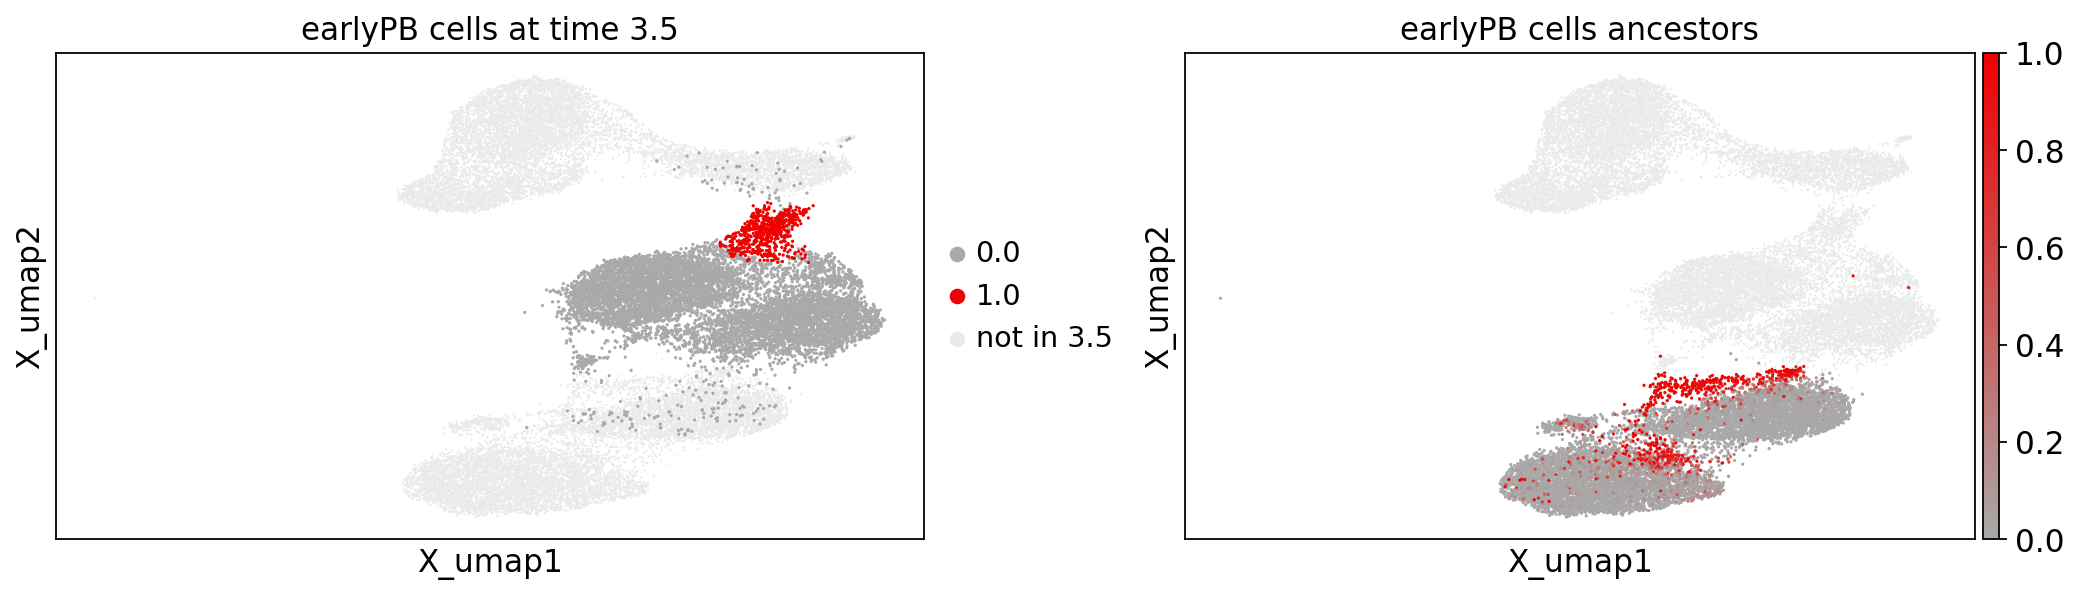

In [29]:
tp0.pull(source=1.5, target=3.5, data="sub_cell_type", subset="earlyPB")
fig, axes = plt.subplots(ncols=2, figsize=(16, 4))

mpl.pull(
    tp0,
    time_points=[3.5],
    basis="X_umap",
    ax=axes[0],
    title=["earlyPB cells at time 3.5"],
)

mpl.pull(
    tp0,
    time_points=[1.5],
    basis="X_umap",
    ax=axes[1],
    title=["earlyPB cells ancestors"],
)

fig.subplots_adjust(wspace=0.3)

In [38]:
tp0.sankey(
    source=3.5,
    target=5.5,
    source_groups={"sub_cell_type": order_celltypes},
    target_groups={"sub_cell_type": order_celltypes},
    threshold=0.05,
    order_annotations=order_celltypes[::-1],
    normalize=True,
)

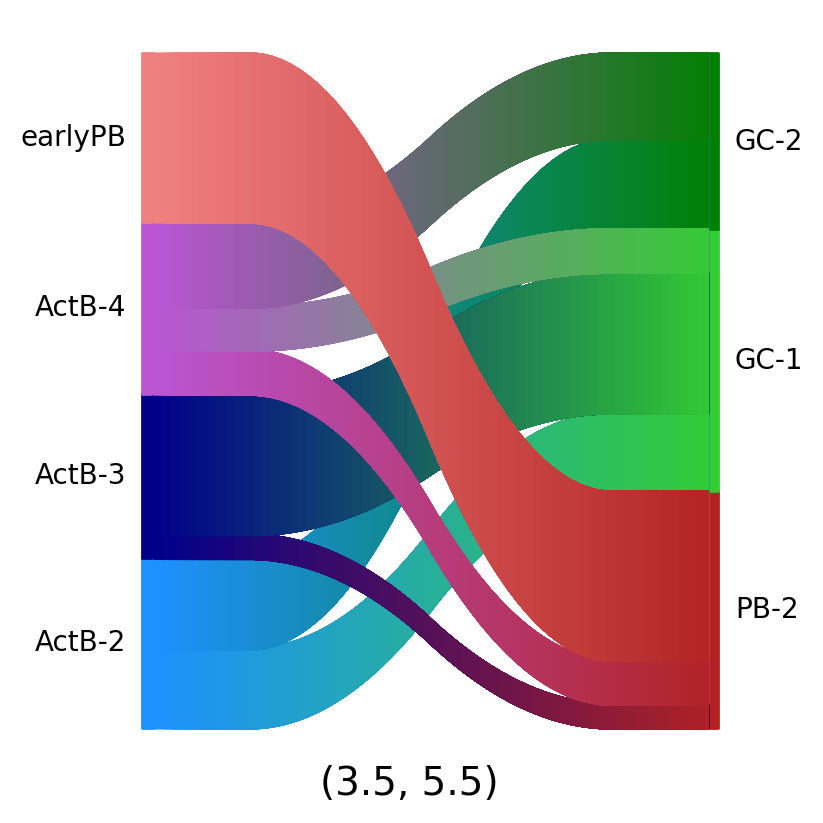

In [39]:
mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True, save="/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/figs/sankey_3.5_5.5.pdf")

In [40]:
tp0.sankey(
    source=1.5,
    target=3.5,
    source_groups={"sub_cell_type": order_celltypes},
    target_groups={"sub_cell_type": order_celltypes},
    threshold=0.05,
    order_annotations=order_celltypes[::-1],
    normalize=True,
)

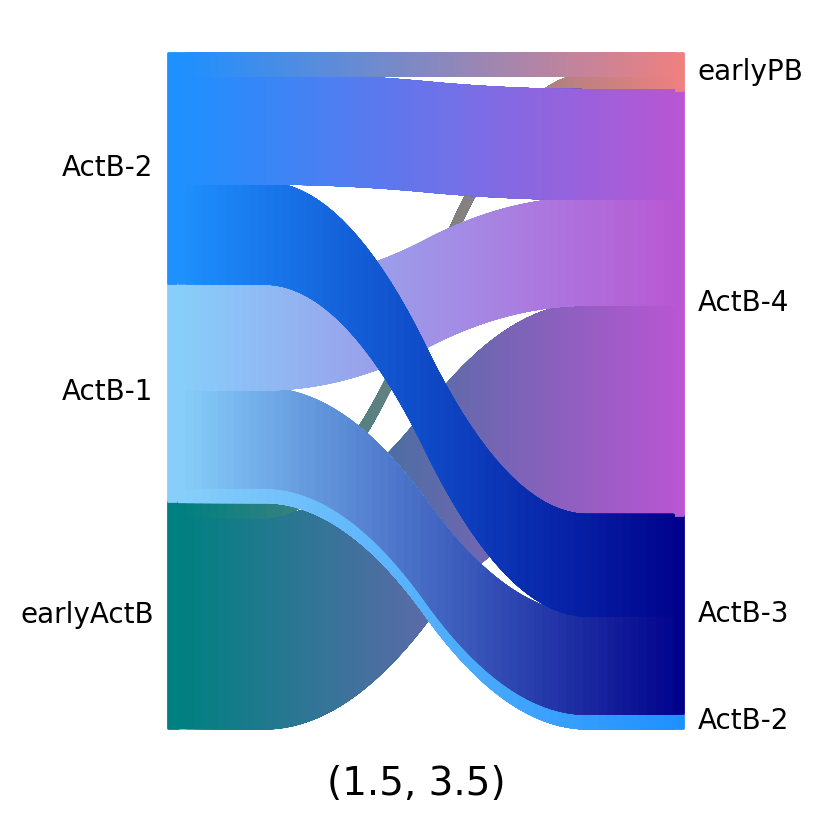

In [41]:
mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True, save="/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/figs/sankey_1.5_3.5.pdf")

# Driver TFs

In [23]:
X_orig = tp0.adata.X.copy()

# 1) Put raw counts into X
tp0.adata.X = tp0.adata.layers["counts"].copy()

# 2) Remove stale flag so scanpy won't warn
tp0.adata.uns.pop("log1p", None)

# 3) Normalize + log1p (now valid because X is counts)
sc.pp.normalize_total(tp0.adata, target_sum=1e4)
sc.pp.log1p(tp0.adata)


[pull] key='ActB-4_GC-2_pull' | combined weight sum = 6915.9983

[result] 38 significant drivers (qval<0.05, |corr|>0.1)


,ActB-4_GC-2_corr,ActB-4_GC-2_pval,ActB-4_GC-2_qval,ActB-4_GC-2_ci_low,ActB-4_GC-2_ci_high,significant
IKZF2,0.490600,0.000000,0.000000,0.474996,0.505894,True
ZBTB20,0.258300,0.000000,0.000000,0.239213,0.277187,True
STAT4,0.243274,0.000000,0.000000,0.224039,0.262320,True
BCL6,0.210869,0.000000,0.000000,0.191346,0.230225,True
NR3C2,0.180154,0.000000,0.000000,0.160398,0.199766,True
PAX5,0.147396,0.000000,0.000000,0.127434,0.167239,True
RUNX1,0.145366,0.000000,0.000000,0.125393,0.165222,True
MXI1,0.127413,0.000000,0.000000,0.107348,0.147375,True
NR4A3,0.126154,0.000000,0.000000,0.106082,0.146123,True
ZNF831,0.113818,0.000000,0.000000,0.093691,0.133852,True


,ActB-4_GC-2_corr,ActB-4_GC-2_pval,ActB-4_GC-2_qval,ActB-4_GC-2_ci_low,ActB-4_GC-2_ci_high,significant
IRF4,-0.298131,0.000000,0.000000,-0.316555,-0.279482,True
PRDM1,-0.291369,0.000000,0.000000,-0.309876,-0.272641,True
BATF,-0.286615,0.000000,0.000000,-0.305180,-0.267833,True
AHR,-0.280017,0.000000,0.000000,-0.298659,-0.261160,True
NFKB1,-0.262054,0.000000,0.000000,-0.280901,-0.243005,True
RUNX2,-0.237791,0.000000,0.000000,-0.256893,-0.218504,True
TCF12,-0.231989,0.000000,0.000000,-0.251148,-0.212649,True
ESR1,-0.231466,0.000000,0.000000,-0.250630,-0.212121,True
XBP1,-0.214571,0.000000,0.000000,-0.233894,-0.195079,True
RELB,-0.189817,0.000000,0.000000,-0.209353,-0.170130,True


/tmp/ipykernel_2810768/2610783663.py:145: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_p = cm.get_cmap(cmap_pos)
/tmp/ipykernel_2810768/2610783663.py:146: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_n = cm.get_cmap(cmap_neg)


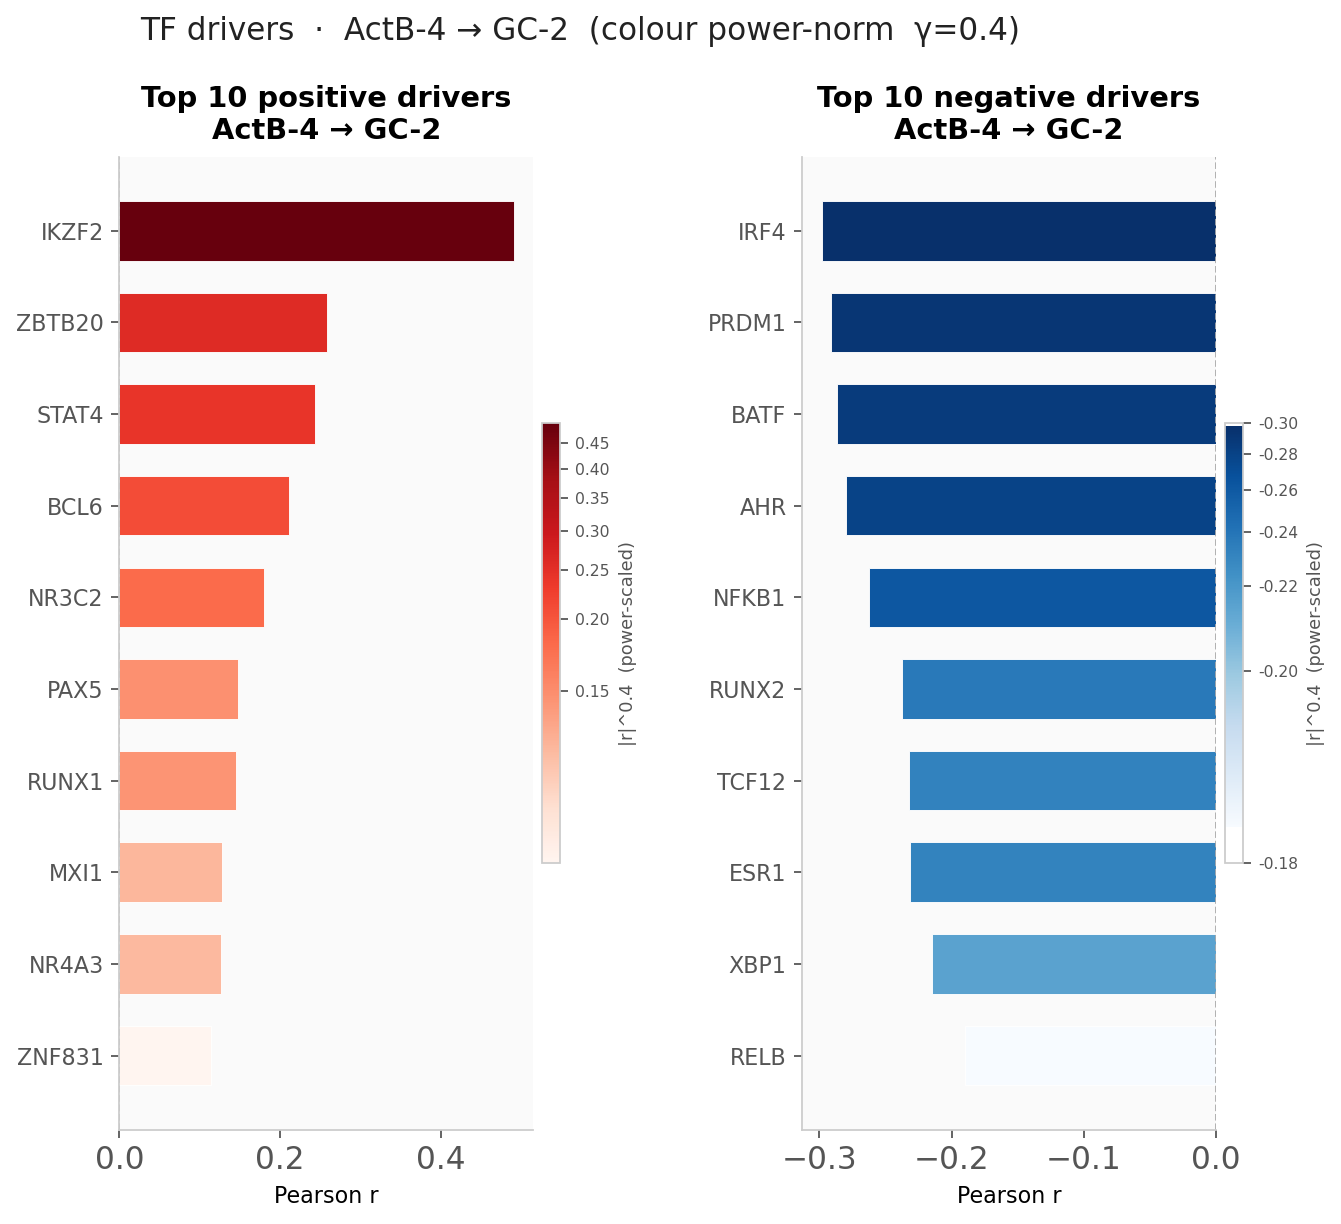

In [31]:
drivers, top_pos, top_neg = drivers_tf_for_subset(
    tp0, subset=("ActB-4", "GC-2")
)

fig = plot_drivers(drivers, subset=("ActB-4", "GC-2"))
# save fig
fig.savefig("/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/figs/tf_drivers_actb4_gc2.pdf", dpi=300)
